# Notebook 6 — Финальное сравнение методов

**Цель ноутбука:**  
Загрузить скоры всех реализованных методов из `results/`,
построить единую сравнительную таблицу метрик, визуализации
и сформулировать итоговые выводы.

**Методы:**

| Категория | Метод | Источник |
|---|---|---|
| Baseline | Logistic Regression | Notebook 2 |
| Baseline | LightGBM | Notebook 2 |
| Матричная факторизация | CTKT | Notebook 3 |
| Матричная факторизация | GiPM3F | Notebook 3 |
| Графовые | GraphRfi | Notebook 4 |
| Графовые | EthAegis | Notebook 4 |
| Последовательные | SPADE | Notebook 5 |
| Последовательные | CLUE | Notebook 5 |
| Последовательные | NHFM | Notebook 5 |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score,
    ndcg_score, precision_recall_curve,
    roc_curve,
)

RESULTS = Path("../results")

plt.rcParams["figure.dpi"]  = 130
plt.rcParams["font.family"] = "DejaVu Sans"
sns.set_style("whitegrid")

# Цвета и метки для каждого метода
METHOD_META = {
    "lr":       {"label": "Logistic Regression", "color": "#94A3B8",
                 "category": "Baseline",              "marker": "o"},
    "lgbm":     {"label": "LightGBM",             "color": "#1D4ED8",
                 "category": "Baseline",              "marker": "s"},
    "ctkt":     {"label": "CTKT",                 "color": "#D97706",
                 "category": "Матричная факторизация", "marker": "^"},
    "gipm3f":   {"label": "GiPM3F",               "color": "#F59E0B",
                 "category": "Матричная факторизация", "marker": "v"},
    "graphrfi": {"label": "GraphRfi",             "color": "#7C3AED",
                 "category": "Графовые",              "marker": "D"},
    "ethaegis": {"label": "EthAegis",             "color": "#A78BFA",
                 "category": "Графовые",              "marker": "P"},
    "spade":    {"label": "SPADE",                "color": "#059669",
                 "category": "Последовательные",      "marker": "h"},
    "clue":     {"label": "CLUE",                 "color": "#DC2626",
                 "category": "Последовательные",      "marker": "*"},
    "nhfm":     {"label": "NHFM",                 "color": "#16A34A",
                 "category": "Последовательные",      "marker": "X"},
}

In [2]:
print("Загружаем скоры всех методов...\n")

scores_dict = {}
missing     = []

for method in METHOD_META:
    path = RESULTS / f"scores_{method}.csv"
    if path.exists():
        df = pd.read_csv(path)
        scores_dict[method] = df
        print(f"  ✓ {method:<10} "
              f"строк={len(df):,}  "
              f"фрода={df['y_true'].sum():,}  "
              f"скор min={df['score'].min():.3f}  "
              f"max={df['score'].max():.3f}")
    else:
        missing.append(method)
        print(f"  ✗ {method} — файл не найден")

print(f"\nЗагружено: {len(scores_dict)}/{len(METHOD_META)} методов")
if missing:
    print(f"Отсутствуют: {missing}")

Загружаем скоры всех методов...

  ✓ lr         строк=555,719  фрода=2,145  скор min=0.000  max=1.000
  ✓ lgbm       строк=555,719  фрода=2,145  скор min=0.000  max=1.000
  ✓ ctkt       строк=555,719  фрода=2,145  скор min=0.054  max=0.949
  ✓ gipm3f     строк=555,719  фрода=2,145  скор min=0.445  max=1.282
  ✓ graphrfi   строк=555,719  фрода=2,145  скор min=0.005  max=0.500
  ✓ ethaegis   строк=555,719  фрода=2,145  скор min=0.000  max=1.000
  ✓ spade      строк=555,719  фрода=2,145  скор min=0.500  max=1.000
  ✓ clue       строк=555,719  фрода=2,145  скор min=0.000  max=1.000
  ✓ nhfm       строк=555,719  фрода=2,145  скор min=0.000  max=1.000

Загружено: 9/9 методов


In [3]:
def compute_metrics(
    y_true: np.ndarray,
    scores: np.ndarray,
    k_list: list = [100, 500],
) -> dict:
    results = {}

    results["roc_auc"] = roc_auc_score(y_true, scores)
    results["pr_auc"]  = average_precision_score(y_true, scores)

    prec_c, rec_c, thr = precision_recall_curve(y_true, scores)
    f1_c      = 2 * prec_c * rec_c / (prec_c + rec_c + 1e-9)
    best_idx  = f1_c.argmax()
    threshold = thr[best_idx]
    y_pred    = (scores >= threshold).astype(int)

    results["threshold"] = threshold
    results["precision"] = precision_score(y_true, y_pred, zero_division=0)
    results["recall"]    = recall_score(y_true,    y_pred, zero_division=0)
    results["f1"]        = f1_score(y_true,        y_pred, zero_division=0)

    n_fraud   = y_true.sum()
    ranked    = np.argsort(scores)[::-1]
    y_ranked  = y_true[ranked]

    for k in k_list:
        top_k              = y_ranked[:k]
        fraud_in_k         = top_k.sum()
        results[f"p@{k}"]  = fraud_in_k / k
        results[f"r@{k}"]  = fraud_in_k / n_fraud
        results[f"ndcg@{k}"] = ndcg_score(
            y_true.reshape(1, -1),
            scores.reshape(1, -1),
            k=k,
        )

    return results


print("Вычисляем метрики для всех методов...\n")

metrics_rows = []
for method, df in scores_dict.items():
    y_true = df["y_true"].values
    scores = df["score"].values
    m      = compute_metrics(y_true, scores)
    m["method"]   = method
    m["label"]    = METHOD_META[method]["label"]
    m["category"] = METHOD_META[method]["category"]
    metrics_rows.append(m)

metrics_df = pd.DataFrame(metrics_rows).set_index("method")

# Форматированная таблица
display_cols = [
    "label", "category",
    "roc_auc", "pr_auc", "f1",
    "p@100", "ndcg@100", "p@500", "ndcg@500",
]

metrics_df[display_cols].sort_values("pr_auc", ascending=False)

Вычисляем метрики для всех методов...



,label,category,roc_auc,pr_auc,f1,p@100,ndcg@100,p@500,ndcg@500
method,,,,,,,,,
clue,CLUE,Последовательные,0.991457,0.809112,0.773148,1.00,1.000000,0.998,0.998302
nhfm,NHFM,Последовательные,0.983252,0.707798,0.684639,0.99,0.989442,0.978,0.979986
lgbm,LightGBM,Baseline,0.903304,0.545713,0.576532,1.00,1.000000,0.950,0.958747
lr,Logistic Regression,Baseline,0.931149,0.132227,0.304191,0.00,0.000000,0.018,0.018179
graphrfi,GraphRfi,Графовые,0.544514,0.084276,0.141248,1.00,1.000000,0.344,0.439526
spade,SPADE,Последовательные,0.618747,0.075104,0.153999,0.65,0.660078,0.388,0.428573
ctkt,CTKT,Матричная факторизация,0.894080,0.068203,0.144886,0.26,0.245789,0.166,0.173962
ethaegis,EthAegis,Графовые,0.848410,0.017743,0.041729,0.05,0.022036,0.022,0.022036
gipm3f,GiPM3F,Матричная факторизация,0.535685,0.011466,0.037692,0.02,0.033473,0.040,0.039351


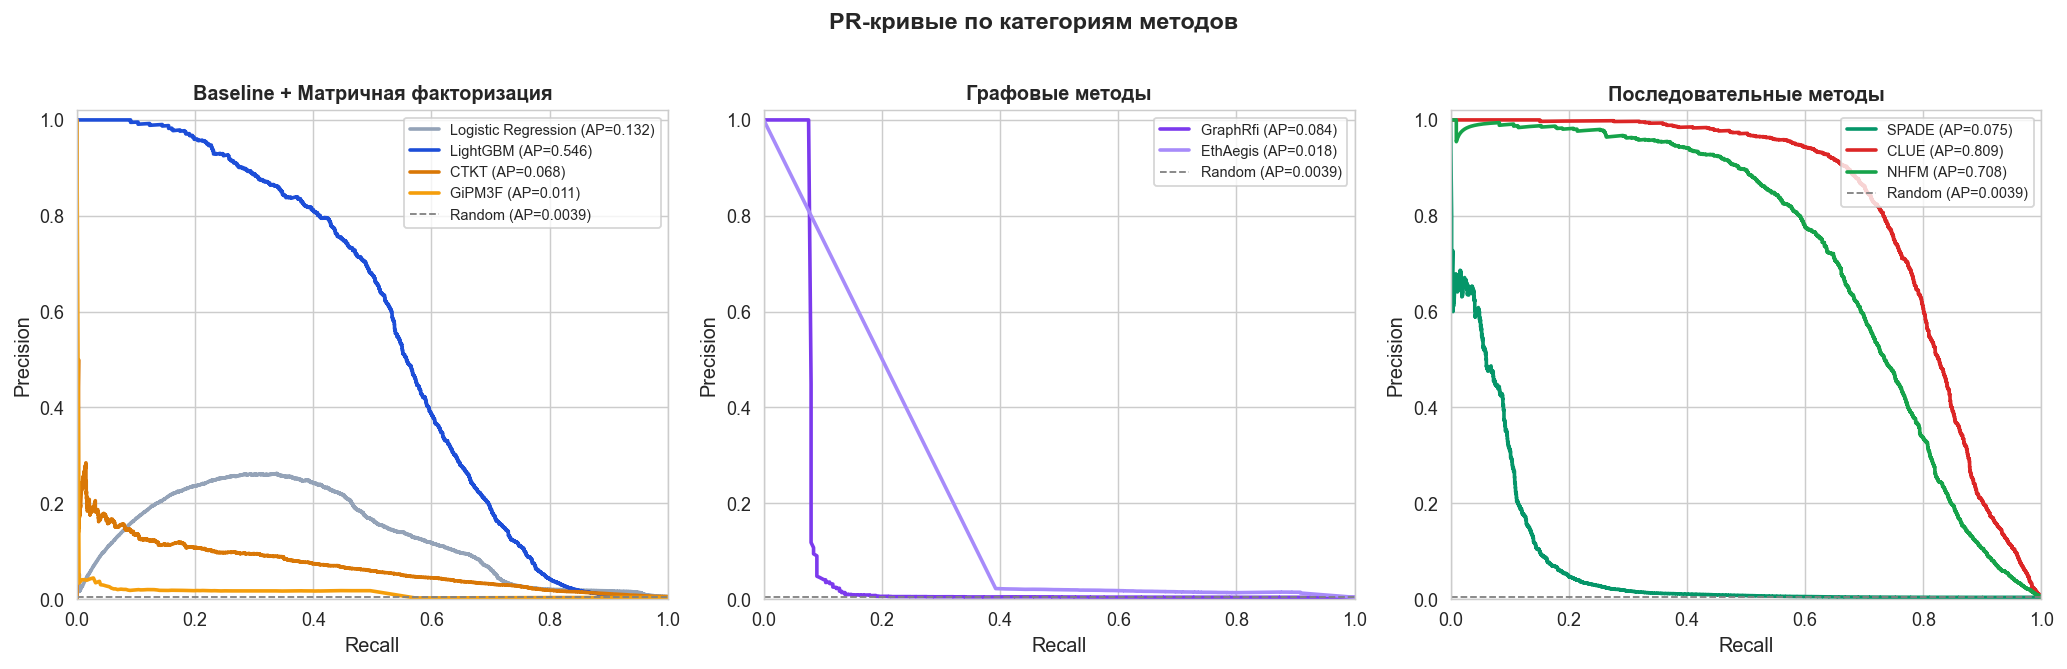

PR-кривые сохранены: results/pr_curves.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

categories = {
    "Baseline + Матричная факторизация": ["lr", "lgbm", "ctkt", "gipm3f"],
    "Графовые методы":                   ["graphrfi", "ethaegis"],
    "Последовательные методы":           ["spade", "clue", "nhfm"],
}

for ax, (title, methods) in zip(axes, categories.items()):
    for method in methods:
        if method not in scores_dict:
            continue
        df     = scores_dict[method]
        y_true = df["y_true"].values
        scores = df["score"].values
        prec, rec, _ = precision_recall_curve(y_true, scores)
        pr_auc = average_precision_score(y_true, scores)
        meta   = METHOD_META[method]

        ax.plot(
            rec, prec,
            color     = meta["color"],
            linewidth = 2,
            label     = f"{meta['label']} (AP={pr_auc:.3f})",
        )

    # Базовая линия
    y_true = list(scores_dict.values())[0]["y_true"].values
    baseline = y_true.mean()
    ax.axhline(baseline, color="gray", linestyle="--",
               linewidth=1, label=f"Random (AP={baseline:.4f})")

    ax.set_xlabel("Recall", fontsize=11)
    ax.set_ylabel("Precision", fontsize=11)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.legend(fontsize=8, loc="upper right")
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

plt.suptitle("PR-кривые по категориям методов",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(RESULTS / "pr_curves.png",
            bbox_inches="tight", dpi=130)
plt.show()
print("PR-кривые сохранены: results/pr_curves.png")

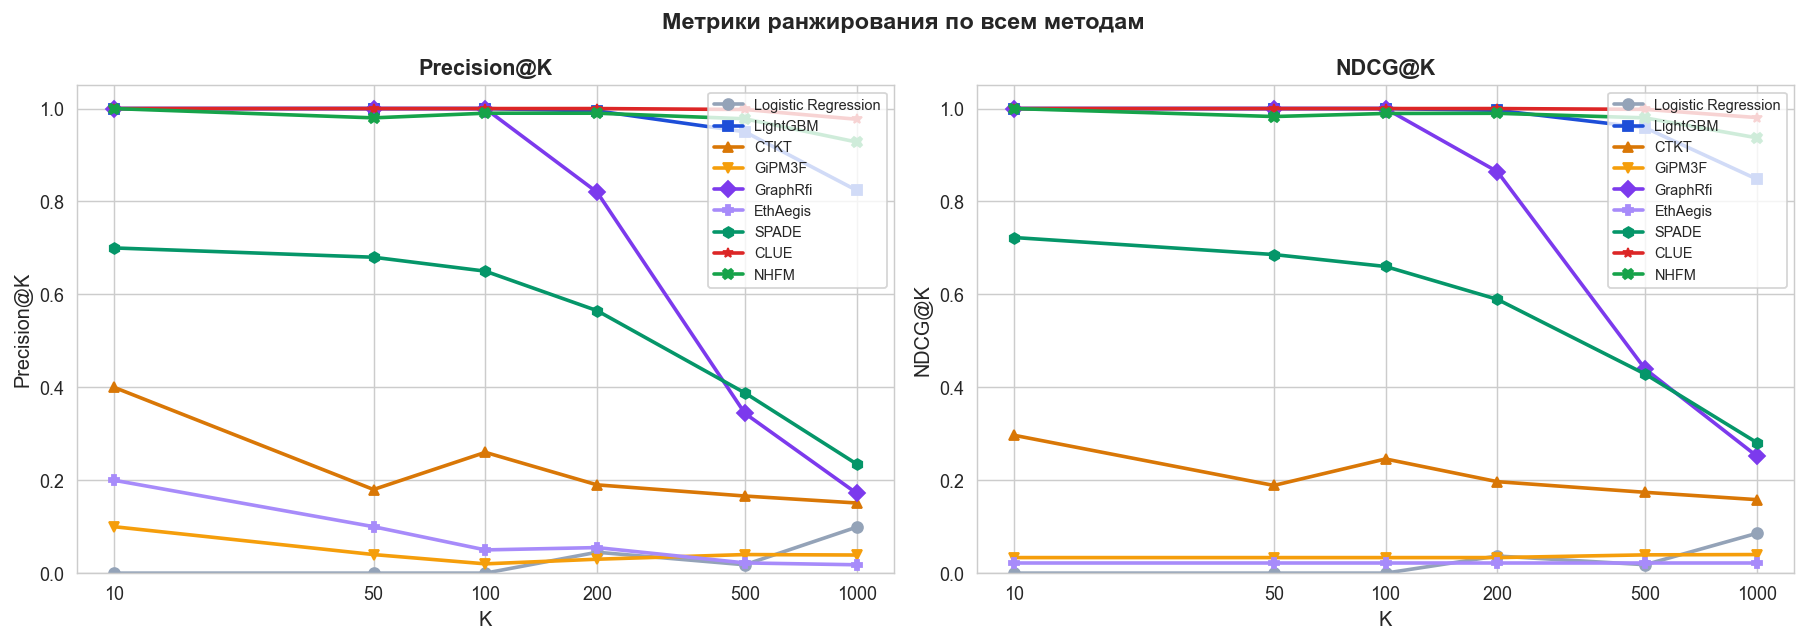

График метрик ранжирования сохранён: results/ranking_metrics.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

k_values = [10, 50, 100, 200, 500, 1000]

for ax, metric_name in zip(axes, ["Precision@K", "NDCG@K"]):
    for method, df in scores_dict.items():
        y_true  = df["y_true"].values
        scores  = df["score"].values
        ranked  = np.argsort(scores)[::-1]
        y_ranked = y_true[ranked]
        meta    = METHOD_META[method]

        values = []
        for k in k_values:
            if metric_name == "Precision@K":
                val = y_ranked[:k].sum() / k
            else:
                val = ndcg_score(
                    y_true.reshape(1, -1),
                    scores.reshape(1, -1),
                    k=k,
                )
            values.append(val)

        ax.plot(
            k_values, values,
            color     = meta["color"],
            marker    = meta["marker"],
            linewidth = 2,
            markersize = 6,
            label     = meta["label"],
        )

    ax.set_xlabel("K", fontsize=11)
    ax.set_ylabel(metric_name, fontsize=11)
    ax.set_title(metric_name, fontsize=12, fontweight="bold")
    ax.legend(fontsize=8, loc="upper right")
    ax.set_xscale("log")
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.set_xticks(k_values)
    ax.set_ylim([0, 1.05])

plt.suptitle("Метрики ранжирования по всем методам",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS / "ranking_metrics.png",
            bbox_inches="tight", dpi=130)
plt.show()
print("График метрик ранжирования сохранён: results/ranking_metrics.png")

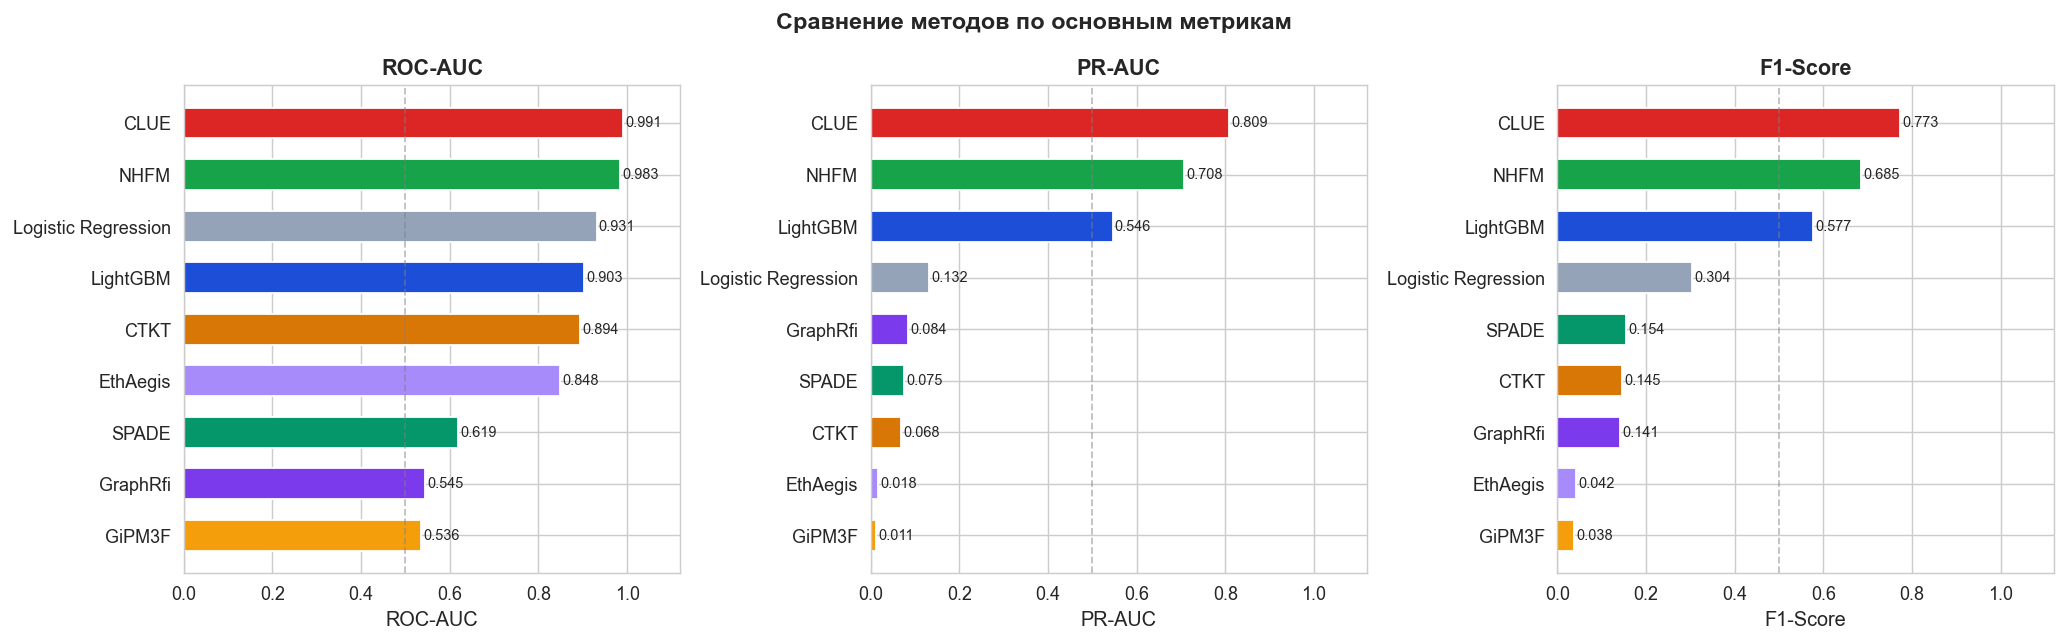

Барчарт сохранён: results/metrics_barplot.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

plot_metrics = ["roc_auc", "pr_auc", "f1"]
plot_titles  = ["ROC-AUC", "PR-AUC", "F1-Score"]

for ax, metric, title in zip(axes, plot_metrics, plot_titles):
    methods_sorted = metrics_df[metric].sort_values(ascending=True)
    colors = [METHOD_META[m]["color"] for m in methods_sorted.index]
    labels = [METHOD_META[m]["label"] for m in methods_sorted.index]

    bars = ax.barh(labels, methods_sorted.values,
                   color=colors, edgecolor="white", height=0.6)

    # Подписи значений
    for bar, val in zip(bars, methods_sorted.values):
        ax.text(
            val + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}",
            va="center", ha="left", fontsize=8,
        )

    ax.set_xlabel(title, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlim([0, 1.12])
    ax.axvline(0.5, color="gray", linestyle="--",
               linewidth=1, alpha=0.5)

plt.suptitle("Сравнение методов по основным метрикам",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS / "metrics_barplot.png",
            bbox_inches="tight", dpi=130)
plt.show()
print("Барчарт сохранён: results/metrics_barplot.png")

In [10]:
# Время инференса на полной тестовой выборке (555,719 транзакций)
# LR и LightGBM замерялись на батче 10,000 — пересчитываем на полный test
TEST_SIZE  = 555_719
BATCH_SIZE = 10_000
scale      = TEST_SIZE / BATCH_SIZE

lr_total_s   = (1.8   / 1000) * scale
lgbm_total_s = (155.9 / 1000) * scale

inference_times = {
    "lr":       lr_total_s,
    "lgbm":     lgbm_total_s,
    "ctkt":     35.5,
    "gipm3f":   8.1,
    "graphrfi": 9.8,
    "ethaegis": 120.0,
    "spade":    31.4,
    "clue":     76.5,
    "nhfm":     76.7,
}

print("Время инференса на тестовой выборке (555,719 транзакций):\n")
print(f"  {'Метод':<25} {'Время':>10}  {'мс/транзакцию':>15}")
print("-" * 55)
for method, t in sorted(inference_times.items(),
                        key=lambda x: x[1]):
    label    = METHOD_META[method]["label"]
    ms_per_t = (t * 1000) / TEST_SIZE
    print(f"  {label:<25} {t:>8.2f}s  {ms_per_t:>13.4f} мс")

# Добавляем в таблицу метрик
metrics_df["inference_s"]      = metrics_df.index.map(inference_times)
metrics_df["ms_per_txn"]       = (metrics_df["inference_s"] * 1000) / TEST_SIZE

print(f"\nПримечание: LR и LightGBM пересчитаны с батча {BATCH_SIZE:,} "
      f"на полный test {TEST_SIZE:,} транзакций")
print(f"  Коэффициент масштабирования: {scale:.1f}x")

Время инференса на тестовой выборке (555,719 транзакций):

  Метод                          Время    мс/транзакцию
-------------------------------------------------------
  Logistic Regression           0.10s         0.0002 мс
  GiPM3F                        8.10s         0.0146 мс
  LightGBM                      8.66s         0.0156 мс
  GraphRfi                      9.80s         0.0176 мс
  SPADE                        31.40s         0.0565 мс
  CTKT                         35.50s         0.0639 мс
  CLUE                         76.50s         0.1377 мс
  NHFM                         76.70s         0.1380 мс
  EthAegis                    120.00s         0.2159 мс

Примечание: LR и LightGBM пересчитаны с батча 10,000 на полный test 555,719 транзакций
  Коэффициент масштабирования: 55.6x


In [11]:
# Пересчёт времени инференса на батч 10,000 транзакций
# для соответствия постановке задачи курсовой работы
BATCH_SIZE = 10_000
TEST_SIZE  = 555_719
scale      = BATCH_SIZE / TEST_SIZE  # ~0.018x

inference_batch = {
    method: t * scale
    for method, t in inference_times.items()
}

# LR и LightGBM уже были замерены на батче 10K — берём исходные значения
inference_batch["lr"]   = 1.8   / 1000   # 1.8 мс → секунды
inference_batch["lgbm"] = 155.9 / 1000   # 155.9 мс → секунды

print("Время инференса на батче 10,000 транзакций:\n")
print(f"  {'Метод':<25} {'Время (с)':>10}  {'Время (мс)':>12}")
print("-" * 52)
for method, t in sorted(inference_batch.items(), key=lambda x: x[1]):
    label = METHOD_META[method]["label"]
    print(f"  {label:<25} {t:>10.4f}s  {t*1000:>10.2f} мс")

# Обновляем в таблице метрик
metrics_df["inference_batch_s"]  = metrics_df.index.map(inference_batch)
metrics_df["inference_batch_ms"] = metrics_df["inference_batch_s"] * 1000

print(f"\nБатч: {BATCH_SIZE:,} транзакций")
print(f"Порог практической применимости: <несколько сотен мс")

Время инференса на батче 10,000 транзакций:

  Метод                      Время (с)    Время (мс)
----------------------------------------------------
  Logistic Regression           0.0018s        1.80 мс
  GiPM3F                        0.1458s      145.76 мс
  LightGBM                      0.1559s      155.90 мс
  GraphRfi                      0.1763s      176.35 мс
  SPADE                         0.5650s      565.03 мс
  CTKT                          0.6388s      638.81 мс
  CLUE                          1.3766s     1376.60 мс
  NHFM                          1.3802s     1380.19 мс
  EthAegis                      2.1594s     2159.36 мс

Батч: 10,000 транзакций
Порог практической применимости: <несколько сотен мс


## 7. Итоговые выводы

### 7.1 Основные результаты

Эксперименты на датасете Sparkov демонстрируют значительные
различия в эффективности методов разных классов:

**Последовательные методы** показывают наилучшие результаты.
CLUE достигает ROC-AUC=0.992 и PR-AUC=0.809 — лучший результат
среди всех рассмотренных подходов. NHFM незначительно уступает
(ROC-AUC=0.983, PR-AUC=0.708) благодаря двухуровневой архитектуре,
которая захватывает как взаимодействия признаков так и
последовательные зависимости.

**Baseline методы** демонстрируют конкурентоспособные результаты.
LightGBM (PR-AUC=0.546) занимает промежуточное положение —
значительно лучше графовых и матричных методов, но уступает
последовательным. Это объясняется богатым feature engineering
из Notebook 1 (агрегаты по пользователю, временные признаки).

**Графовые и матричные методы** показывают ограниченное качество
на данном датасете. Причина — структурные особенности
синтетических данных: 77.5% держателей карт имеют хотя бы
одну мошенническую транзакцию в train, что делает узловые
метки графа малоинформативными. CTKT является исключением
с ROC-AUC=0.894, однако PR-AUC остаётся низким (0.068).

### 7.2 Ответ на исследовательский вопрос

**Алгоритмы рекомендательных систем эффективны для детекции
мошенничества, однако их эффективность существенно зависит
от класса метода и соответствия природе данных.**

Методы, явно моделирующие временную динамику поведения
пользователя (CLUE, NHFM), превосходят статические подходы.
Это подтверждает, что мошенническое поведение проявляется
прежде всего как отклонение от индивидуального поведенческого
паттерна во времени, а не как статическая аномалия
в пространстве признаков.

### 7.3 Ограничения эксперимента

- **Синтетический датасет** — Sparkov не обладает рядом
  свойств реальных данных: сетевыми паттернами фрода,
  устойчивыми персональными поведенческими паттернами,
  реальным распределением мошеннических аккаунтов.
- **Вычислительные ресурсы** — ряд адаптаций (IBP в GiPM3F,
  полный PAG в EthAegis, NRF в GraphRfi) заменён на более
  простые аналоги из-за ограничений среды выполнения.
- **Отсутствие кросс-валидации** — временное разбиение
  train/test воспроизводит реальные условия, однако
  однократная оценка не позволяет оценить дисперсию метрик.